In [224]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import pickle
import warnings
warnings.filterwarnings('ignore')

In [225]:
df=pd.read_csv("../data/heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [226]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [227]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [228]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [229]:
df.duplicated().sum()

np.int64(0)

In [230]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

EDA

In [231]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

Target Distribution (count plot)

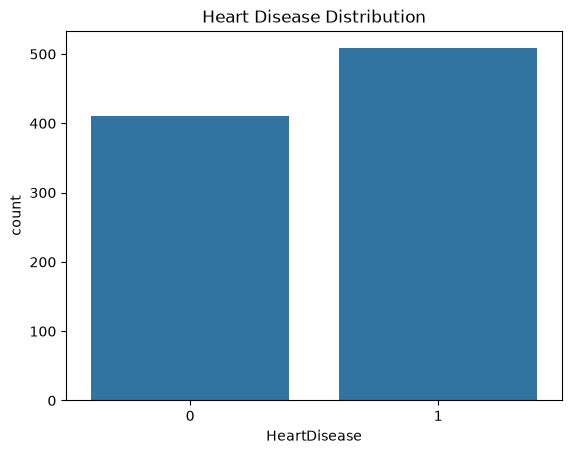

In [232]:
sns.countplot(x="HeartDisease",data=df)
plt.title("Heart Disease Distribution")
plt.show()

Age Distribution (histogram plot)

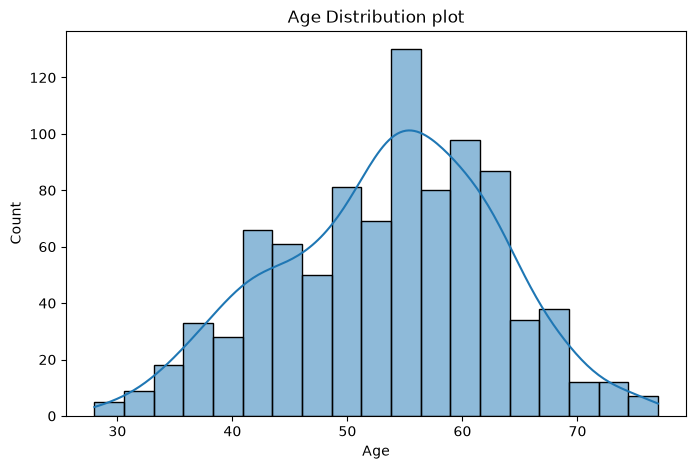

In [233]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"],kde=True)
plt.title("Age Distribution plot")
plt.show()

Gender Distribution (count plot)

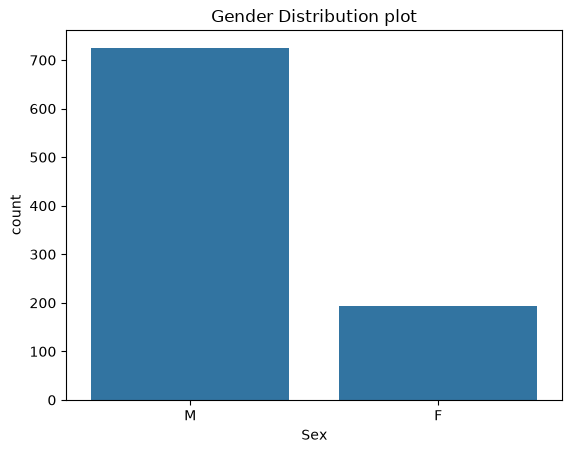

In [234]:
sns.countplot(x='Sex',data=df)
plt.title("Gender Distribution plot")
plt.show()

Chest pain vs Heart Disease

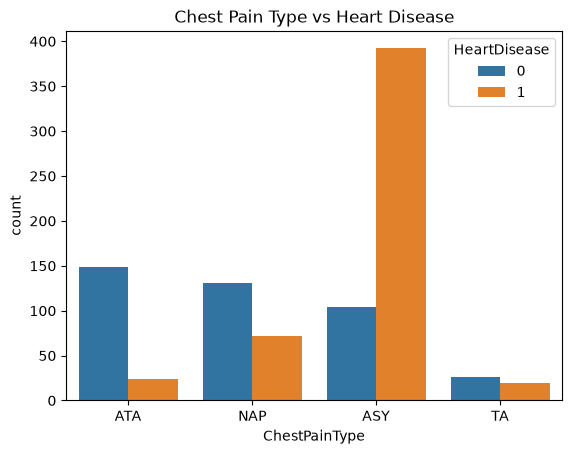

In [235]:
sns.countplot(x='ChestPainType', hue='HeartDisease', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

Correlation Heatmap

In [236]:
plt.figure(figsize=(12,8))
hcorr=df[['Age','Cholesterol','MaxHR','RestingBP','HeartDisease']]
hcorr.corr()


,Age,Cholesterol,MaxHR,RestingBP,HeartDisease
Age,1.000000,-0.095282,-0.382045,0.254399,0.282039
Cholesterol,-0.095282,1.000000,0.235792,0.100893,-0.232741
MaxHR,-0.382045,0.235792,1.000000,-0.112135,-0.400421
RestingBP,0.254399,0.100893,-0.112135,1.000000,0.107589
HeartDisease,0.282039,-0.232741,-0.400421,0.107589,1.000000


<Figure size 1200x800 with 0 Axes>

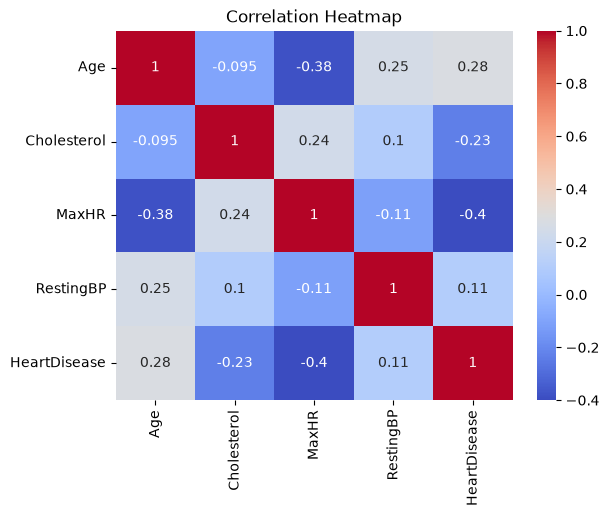

In [237]:
sns.heatmap(
    hcorr.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

Cholesterol Boxplot

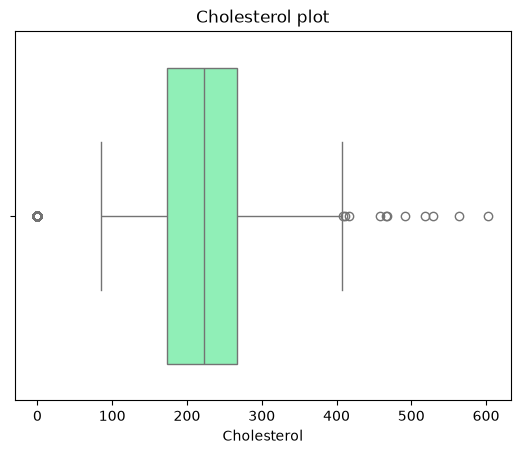

In [238]:
sns.boxplot(x="Cholesterol",data=df,palette='rainbow')
plt.title('Cholesterol plot')
plt.show()

Split the data

In [239]:
X=df.drop('HeartDisease',axis=1)
Y=df['HeartDisease']

In [240]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [241]:
X_train.shape

(734, 11)

In [242]:
X_test.shape

(184, 11)

In [243]:
X_train.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope'],
      dtype='str')

In [244]:
X_test.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope'],
      dtype='str')

In [245]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 734 entries, 795 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             734 non-null    int64  
 1   Sex             734 non-null    str    
 2   ChestPainType   734 non-null    str    
 3   RestingBP       734 non-null    int64  
 4   Cholesterol     734 non-null    int64  
 5   FastingBS       734 non-null    int64  
 6   RestingECG      734 non-null    str    
 7   MaxHR           734 non-null    int64  
 8   ExerciseAngina  734 non-null    str    
 9   Oldpeak         734 non-null    float64
 10  ST_Slope        734 non-null    str    
dtypes: float64(1), int64(5), str(5)
memory usage: 68.8 KB


In [246]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')


In [247]:
cat_cols=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

In [248]:
from sklearn.preprocessing import OneHotEncoder

In [249]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

In [250]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_cat)
X_test_scaled = scaler.transform(X_test_cat)

feature reduces due toh OHE

In [253]:
X_train_scaled.shape

(734, 9)

In [254]:
lr = LogisticRegression()
lr.fit(X_train_scaled, Y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [255]:
acc_lr = accuracy_score(Y_test, y_pred_lr)
print("Accuracy:", acc_lr)

Accuracy: 0.8260869565217391


In [256]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_scaled, Y_train)

y_pred_dt = dt.predict(X_test_scaled)

acc_dt = accuracy_score(Y_test, y_pred_dt)

print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.782608695652174


In [257]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_scaled, Y_train)

y_pred_rf = rf.predict(X_test_scaled)

acc_rf = accuracy_score(Y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.8097826086956522


In [258]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [acc_lr, acc_dt, acc_rf]
})

results

,Model,Accuracy
0,Logistic Regression,0.826087
1,Decision Tree,0.782609
2,Random Forest,0.809783


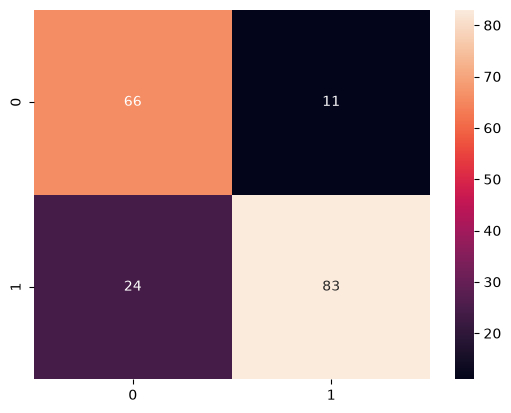

In [259]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [260]:
print(rf.n_features_in_)

9


In [262]:
import pickle

pickle.dump(rf, open('../models/heart_disease_model.pkl', 'wb'))

In [265]:
pickle.dump(scaler, open('../models/scaler.pkl','wb'))
pickle.dump(ohe, open('../models/encoder.pkl','wb'))


In [266]:
print(model.n_features_in_)

9


In [270]:
import pickle
import pandas as pd

# Load model and encoder
model = pickle.load(open('../models/heart_disease_model.pkl', 'rb'))
encoder = pickle.load(open('../models/encoder.pkl', 'rb'))

# Input categorical values only
sample = pd.DataFrame({
    'Sex': ['M'],
    'ChestPainType': ['ATA'],
    'RestingECG': ['Normal'],
    'ExerciseAngina': ['N'],
    'ST_Slope': ['Up']
})

# Encode
sample_encoded = encoder.transform(sample)

# Predict
prediction = model.predict(sample_encoded)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

No Heart Disease
